In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [3]:
data_path = Path("../data") / "bnd.csv"
if not data_path.exists():
    raise FileNotFoundError(f"{data_path} not found. Expected [data/bnd_df.csv](data/bnd_df.csv)")

bnd_df = pd.read_csv(data_path, index_col=0, parse_dates=True)

C:\Users\mijuu\AppData\Local\Temp\ipykernel_19448\1051974790.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bnd_df = pd.read_csv(data_path, index_col=0, parse_dates=True)


In [4]:
bnd_df.head()

,Close,High,Low,Open,Volume
Price,,,,,
Ticker,BND,BND,BND,BND,BND
Date,NaN,NaN,NaN,NaN,NaN
2015-01-02,59.40544509887695,59.43419612304385,59.24012808084159,59.247317207807605,2218800
2015-01-05,59.577919006347656,59.59948089386604,59.44135307380497,59.470104085061045,5820100
2015-01-06,59.75039291381836,59.93008254117295,59.678518159614974,59.678518159614974,3887600


In [5]:
bnd_df.tail()

,Close,High,Low,Open,Volume
Price,,,,,
2026-06-23,72.97663116455078,73.05636708397215,72.93676320484009,72.93676320484009,7081800
2026-06-24,73.30553436279297,73.3553636082038,73.21582955459647,73.2357673359893,7819400
2026-06-25,73.3553695678711,73.48494234534462,73.34540067636476,73.40520642136649,7638100
2026-06-26,73.42513275146484,73.47496960234783,73.31549776275094,73.32546665373471,5965100
2026-06-29,73.46500396728516,73.48494175013631,73.39523693537845,73.44507378847017,7224800


In [6]:
bnd_df.shape

(2890, 5)

In [7]:
bnd_df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [8]:
bnd_df.info()

<class 'pandas.DataFrame'>
Index: 2890 entries, Ticker to 2026-06-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Close   2889 non-null   str  
 1   High    2889 non-null   str  
 2   Low     2889 non-null   str  
 3   Open    2889 non-null   str  
 4   Volume  2889 non-null   str  
dtypes: str(5)
memory usage: 135.5+ KB


In [9]:
bnd_df.index

Index(['Ticker', 'Date', '2015-01-02', '2015-01-05', '2015-01-06',
       '2015-01-07', '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
       ...
       '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-22',
       '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-29'],
      dtype='str', name='Price', length=2890)

In [10]:
bnd_df.isnull().sum()

Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

In [11]:
bnd_df[bnd_df["Low"].isnull()]

,Close,High,Low,Open,Volume
Price,,,,,
Date,NaN,NaN,NaN,NaN,NaN


In [12]:
bnd_df.duplicated().sum()

np.int64(0)

In [13]:
bnd_df.describe()

,Close,High,Low,Open,Volume
count,2889,2889,2889,2889,2889
unique,2626,2874,2869,2881,2841
top,59.522037506103516,60.00744603390389,59.88299616447688,59.77742581183843,1827800
freq,5,2,3,2,3


In [14]:
for col in ["Close", "High", "Low", "Open"]:
    bnd_df[col] = pd.to_numeric(bnd_df[col], errors="coerce")

bnd_df["Volume"] = pd.to_numeric(bnd_df["Volume"], errors="coerce").astype("Int64")



In [15]:
bnd_df.index = pd.to_datetime(bnd_df.index, errors="coerce")
bnd_df = bnd_df[bnd_df.index.notna()].copy()

C:\Users\mijuu\AppData\Local\Temp\ipykernel_19448\1304337960.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bnd_df.index = pd.to_datetime(bnd_df.index, errors="coerce")


In [16]:
import os

out_dir = os.path.join("..", "data", "processed")
os.makedirs(out_dir, exist_ok=True)

bnd_df.to_csv(os.path.join(out_dir, "bnd.csv"), index=False)

In [53]:
bnd_df.head()

,Close,High,Low,Open,Volume,Daily_Return,Rolling_Mean,Rolling_STD
Price,,,,,,,,
2015-01-02,59.405445,59.434196,59.240128,59.247317,2218800,NaN,NaN,NaN
2015-01-05,59.577919,59.599481,59.441353,59.470104,5820100,0.002903,NaN,NaN
2015-01-06,59.750393,59.930083,59.678518,59.678518,3887600,0.002895,NaN,NaN
2015-01-07,59.786343,59.858217,59.692906,59.757592,2433400,0.000602,NaN,NaN
2015-01-08,59.692902,59.736025,59.635400,59.736025,1873400,-0.001563,NaN,NaN


visualization 

closing price over time 

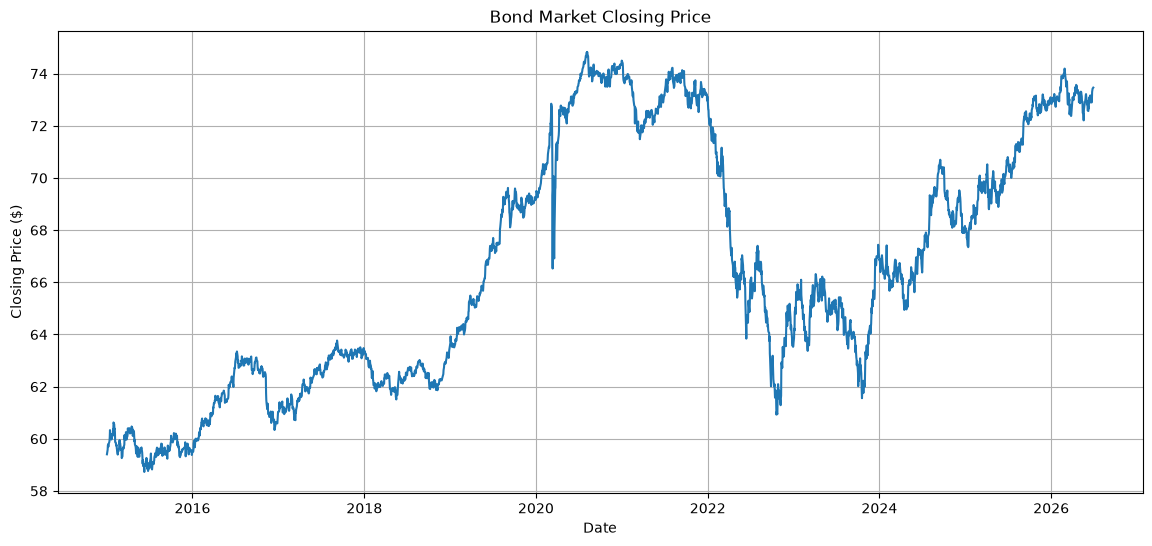

In [17]:
plt.figure(figsize=(14,6))

plt.plot(bnd_df.index, bnd_df["Close"])

plt.title("Bond Market Closing Price")

plt.xlabel("Date")

plt.ylabel("Closing Price ($)")

plt.grid(True)

plt.show()

Daily Percentage Returns
how much the investment gained 

In [18]:
bnd_df["Daily_Return"] = bnd_df["Close"].pct_change()

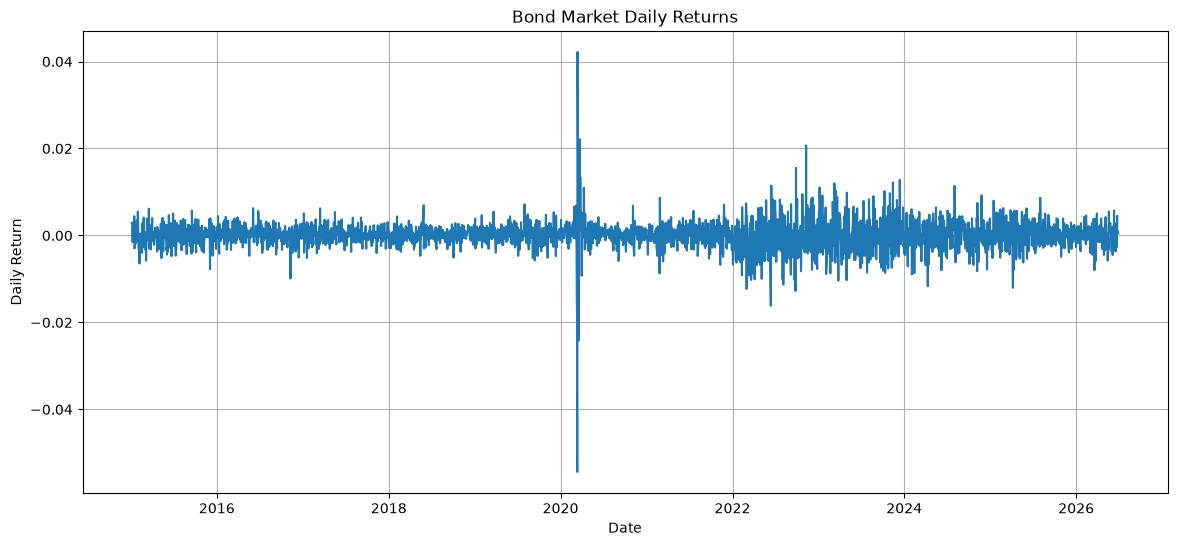

In [19]:
plt.figure(figsize=(14,6))

plt.plot(bnd_df.index,
         bnd_df["Daily_Return"])

plt.title("Bond Market Daily Returns")

plt.xlabel("Date")

plt.ylabel("Daily Return")

plt.grid(True)

plt.show()

In [20]:
window = 30

bnd_df["Rolling_Mean"] = (
    bnd_df["Close"]
    .rolling(window)
    .mean()
)

bnd_df["Rolling_STD"] = (
    bnd_df["Close"]
    .rolling(window)
    .std()
)

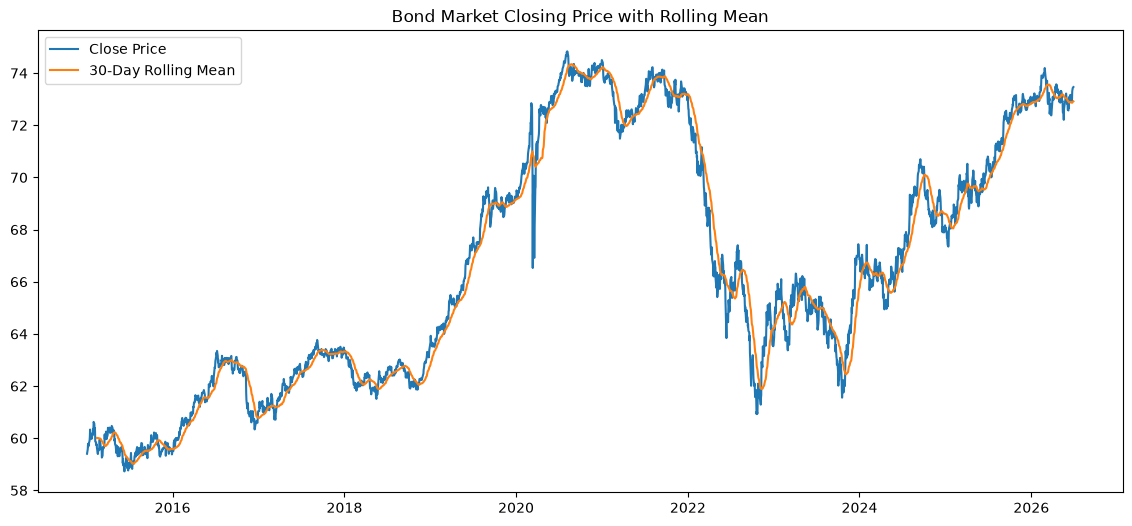

In [21]:
plt.figure(figsize=(14,6))

plt.plot(bnd_df["Close"],
         label="Close Price")

plt.plot(bnd_df["Rolling_Mean"],
         label="30-Day Rolling Mean")

plt.legend()

plt.title("Bond Market Closing Price with Rolling Mean")

plt.show()

outlier     

In [22]:
Q1 = bnd_df["Daily_Return"].quantile(0.25)
Q3 = bnd_df["Daily_Return"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = bnd_df[
    (bnd_df["Daily_Return"] < lower) |
    (bnd_df["Daily_Return"] > upper)
]

In [23]:
outliers.head()

,Close,High,Low,Open,Volume,Daily_Return,Rolling_Mean,Rolling_STD
Price,,,,,,,,
2015-02-06,59.871071,60.079932,59.856669,60.051123,2907700,-0.006454,NaN,NaN
2015-12-03,59.329273,59.652715,59.307221,59.652715,2510600,-0.007745,59.663563,0.247096
2016-11-09,61.745651,62.129213,61.685484,62.046484,3448800,-0.009889,62.599143,0.245156
2018-05-29,62.569454,62.647979,62.239647,62.255349,2414400,0.006950,61.893574,0.228234
2019-08-01,68.037979,68.070612,67.662710,67.687184,3278400,0.007161,67.417165,0.175933


In [24]:
outliers.sort_values("Daily_Return")

,Close,High,Low,Open,Volume,Daily_Return,Rolling_Mean,Rolling_STD
Price,,,,,,,,
2020-03-12,66.528351,70.304887,63.348105,69.137145,16986900,-0.054385,70.869574,1.132863
2020-03-18,66.959015,68.466317,66.511793,67.447649,10076800,-0.024140,70.648307,1.416736
2020-03-17,68.615395,70.164109,68.565705,69.195130,13629700,-0.020685,70.758193,1.237185
2020-03-11,70.354553,72.251104,70.288303,71.870138,10511600,-0.018940,70.996503,0.791613
2022-06-13,64.188896,64.667920,63.901488,64.633082,11255300,-0.016153,66.066495,0.548666
...,...,...,...,...,...,...,...,...
2022-09-28,62.975956,63.002242,62.467730,62.590405,11649700,0.015543,64.636742,1.138481
2020-03-20,68.052185,68.366900,66.826471,66.834748,8864500,0.016955,70.469101,1.634200
2022-11-10,62.926086,62.926086,62.397963,62.406767,7014100,0.020702,61.901466,0.590605


C:\Users\mijuu\AppData\Local\Temp\ipykernel_19448\1139626101.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


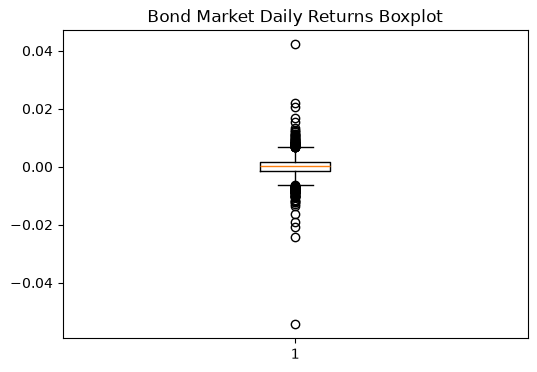

In [25]:
plt.figure(figsize=(6,4))

plt.boxplot(
    bnd_df["Daily_Return"].dropna(),
    vert=True
)

plt.title("Bond Market Daily Returns Boxplot")

plt.show()

In [26]:
from statsmodels.tsa.stattools import adfuller

In [27]:
result = adfuller(
    bnd_df["Close"].dropna()
)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.0827092586730511
p-value: 0.7219177694808669


we fail to reject the null hypothesis. thus it is not stationary ( close price)

In [28]:
result_returns = adfuller(
    bnd_df["Daily_Return"].dropna()
)

print("ADF Statistic:", result_returns[0])
print("p-value:", result_returns[1])

ADF Statistic: -15.216079424708543
p-value: 5.568117280698332e-28


## Risk metrics

### VaR

In [29]:
returns = bnd_df["Daily_Return"].dropna()

In [30]:
VaR_95 = returns.quantile(0.05)

print(VaR_95)

-0.004756572434969963


The historical 95% Value at Risk (VaR) for Tesla is approximately -0.4%, meaning that on 95% of trading days the daily loss is expected to be less than 0.4%, while only about 5% of trading days experience larger losses.

### Sharpe Ratio

"How much return am I getting for every unit of risk I take?"

In [31]:
mean_return = returns.mean()

In [32]:
std_return = returns.std()

In [33]:
annual_return = mean_return * 252

In [34]:
annual_volatility = std_return * np.sqrt(252)

In [35]:
risk_free_rate = 0

In [36]:
sharpe_ratio = (
    annual_return - risk_free_rate
) / annual_volatility

print(sharpe_ratio)

0.3755869579802189


For each unit of risk, the investment generated 0.37 units of return.

# model training  

In [37]:
bnd = bnd_df[["Close"]].copy()

In [38]:
train = bnd.loc[:'2024-12-31']

test = bnd.loc['2025-01-01':]

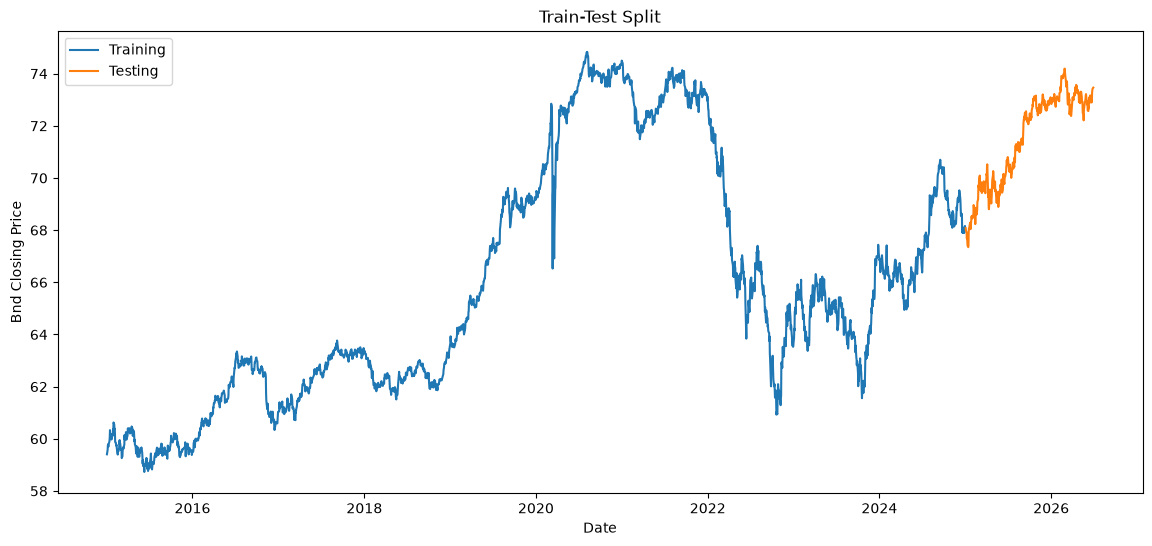

In [39]:
plt.figure(figsize=(14,6))

plt.plot(train.index,
         train["Close"],
         label="Training")

plt.plot(test.index,
         test["Close"],
         label="Testing")

plt.title("Train-Test Split")

plt.xlabel("Date")

plt.ylabel("Bnd Closing Price")

plt.legend()

plt.show()

In [40]:
from pmdarima import auto_arima

In [41]:
model = auto_arima(
    train["Close"],
    seasonal=False,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

Performing stepwise search to minimize aic


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-320.649, Time=1.39 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-281.457, Time=0.24 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-279.463, Time=0.16 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-279.464, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-282.889, Time=0.13 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-298.509, Time=1.61 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-301.146, Time=1.14 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-318.698, Time=2.73 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-318.700, Time=2.78 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-283.297, Time=0.81 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-299.868, Time=3.54 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-301.615, Time=1.23 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=-316.737, Time=3.59 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=-321.997, Time=0.82 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-299.798, Time=0.44 sec
 ARIMA(2,1

In [42]:
forecast = model.predict(
    n_periods=len(test)
)

c:\Users\mijuu\Documents\mijuuhailu\time-series-forecast\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\mijuu\Documents\mijuuhailu\time-series-forecast\myenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


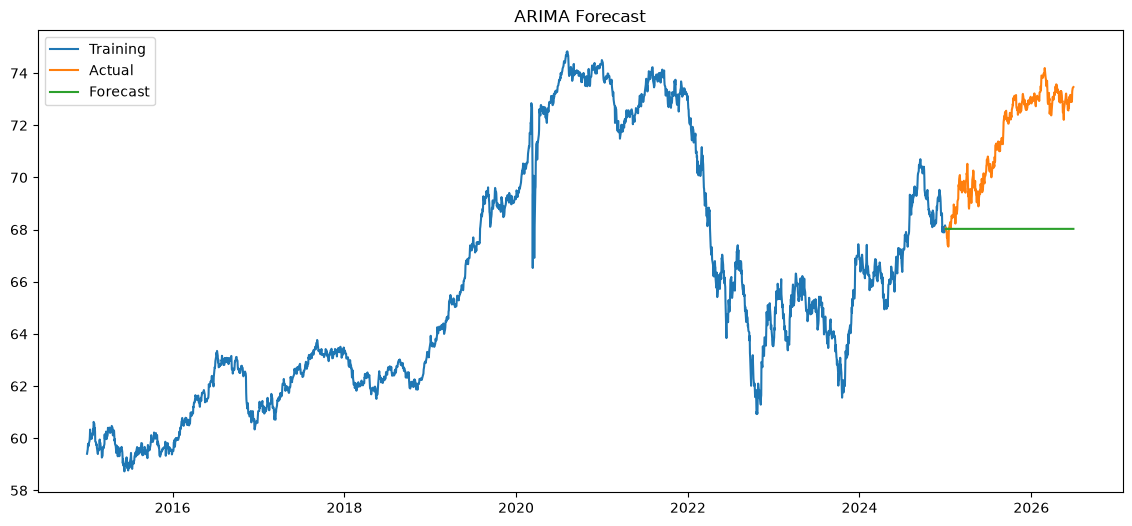

In [43]:
plt.figure(figsize=(14,6))

plt.plot(train.index,
         train["Close"],
         label="Training")

plt.plot(test.index,
         test["Close"],
         label="Actual")

plt.plot(test.index,
         forecast,
         label="Forecast")

plt.legend()

plt.title("ARIMA Forecast")

plt.show()

## evaluation metrics 

### ARIMA

In [44]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [45]:
mae = mean_absolute_error(
    test["Close"],
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test["Close"],
        forecast
    )
)

mape = mean_absolute_percentage_error(
    test["Close"],
    forecast
)

In [46]:
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.4f}")

MAE : 3.48
RMSE: 3.89
MAPE: 0.0481


### LSTM

Training Shape: (2456, 60, 1)
Epoch 1/20


c:\Users\mijuu\Documents\mijuuhailu\time-series-forecast\myenv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0425
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0046
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0037
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0034
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0029
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0029
Epoch 7/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0025
Epoch 8/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0024
Epoch 9/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0022
Epoch 10/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0023
Epoch 11/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0021
Epoch 12/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0020
Epoch 13/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0021
Epoch 14/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0020
Epoch 15/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0019
Epoch 16/20
77/

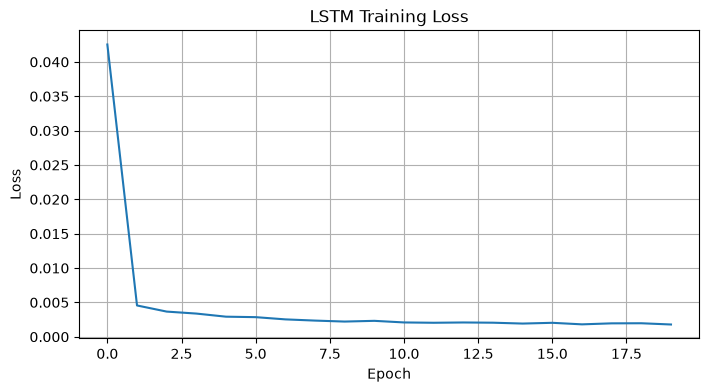

In [47]:
# =====================================================
# LSTM MODEL FOR TESLA STOCK PRICE FORECASTING
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# =====================================================
# 1. Select Closing Prices
# =====================================================

bnd = bnd_df[['Close']].copy()

# =====================================================
# 2. Train-Test Split (Chronological)
# =====================================================

train = bnd.loc[:'2024-12-31']
test = bnd.loc['2025-01-01':]

# =====================================================
# 3. Scale the Data
# =====================================================

scaler = MinMaxScaler(feature_range=(0,1))

scaled_train = scaler.fit_transform(train)
scaled_test = scaler.transform(test)

# =====================================================
# 4. Create Training Sequences
# =====================================================

window = 60

X_train = []
y_train = []

for i in range(window, len(scaled_train)):
    X_train.append(scaled_train[i-window:i, 0])
    y_train.append(scaled_train[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

# =====================================================
# 5. Reshape for LSTM
# Shape = (samples, time_steps, features)
# =====================================================

X_train = X_train.reshape((X_train.shape[0],
                           X_train.shape[1],
                           1))

print("Training Shape:", X_train.shape)

# =====================================================
# 6. Build the LSTM Model
# =====================================================

model = Sequential()


model.add(
    LSTM(
        units=50,
        input_shape=(window,1)
    )
)
model.add(Dropout(0.2))

model.add(Dense(1))

# =====================================================
# 7. Compile
# =====================================================

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# =====================================================
# 8. Train
# =====================================================

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)

# =====================================================
# 9. Plot Training Loss
# =====================================================

plt.figure(figsize=(8,4))

plt.plot(history.history['loss'])

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

c:\Users\mijuu\Documents\mijuuhailu\time-series-forecast\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Test Shape: (372, 60, 1)
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


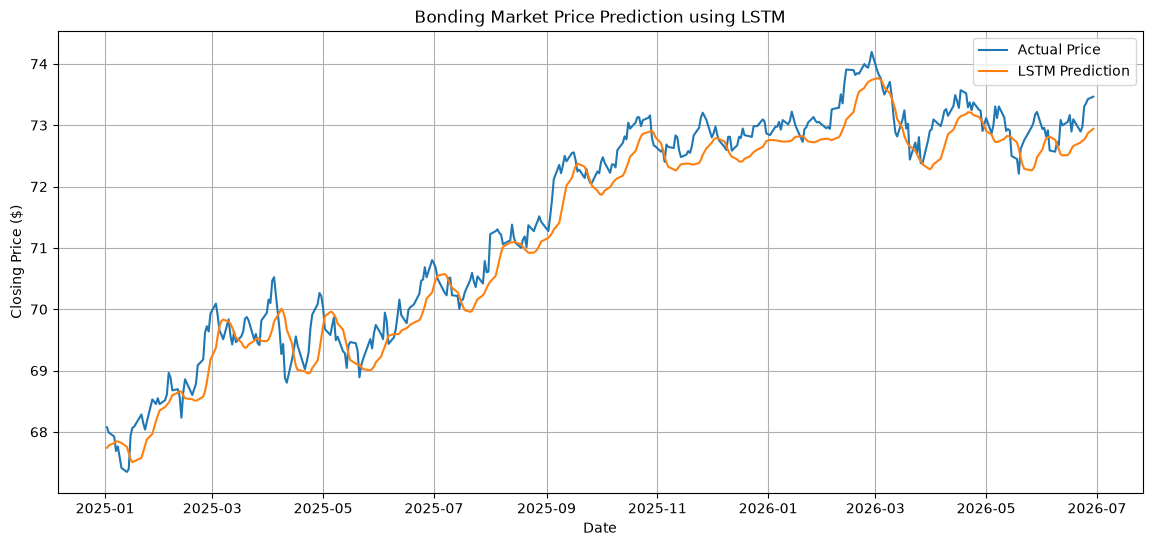

LSTM MAE : 0.33
LSTM RMSE: 0.39
LSTM MAPE: 0.46%

Model Comparison
   Model        MAE       RMSE   MAPE (%)
0  ARIMA  54.440000  70.540000  17.240000
1   LSTM   0.328474   0.392912   0.459622


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# ============================================
# Prepare Test Data
# ============================================

dataset_total = pd.concat(
    (train["Close"], test["Close"]),
    axis=0
)

inputs = dataset_total[
    len(dataset_total) - len(test) - window:
].values

inputs = inputs.reshape(-1,1)

inputs = scaler.transform(inputs)

# ============================================
# Create Test Sequences
# ============================================

X_test = []

for i in range(window, len(inputs)):
    X_test.append(inputs[i-window:i,0])

X_test = np.array(X_test)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("Test Shape:", X_test.shape)

# ============================================
# Predict
# ============================================

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

# ============================================
# Plot
# ============================================

plt.figure(figsize=(14,6))

plt.plot(
    test.index,
    test["Close"],
    label="Actual Price"
)

plt.plot(
    test.index,
    predictions,
    label="LSTM Prediction"
)

plt.title("Bonding Market Price Prediction using LSTM")

plt.xlabel("Date")

plt.ylabel("Closing Price ($)")

plt.legend()

plt.grid(True)

plt.show()

# ============================================
# Evaluation
# ============================================

mae = mean_absolute_error(
    test["Close"],
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test["Close"],
        predictions
    )
)

mape = mean_absolute_percentage_error(
    test["Close"],
    predictions
)

print(f"LSTM MAE : {mae:.2f}")
print(f"LSTM RMSE: {rmse:.2f}")
print(f"LSTM MAPE: {mape*100:.2f}%")

# ============================================
# Compare with ARIMA
# ============================================

comparison = pd.DataFrame({
    "Model": ["ARIMA", "LSTM"],
    "MAE": [54.44, mae],
    "RMSE": [70.54, rmse],
    "MAPE (%)": [17.24, mape*100]
})

print("\nModel Comparison")
print(comparison)

# prediction

In [49]:
future_days = 252

last_sequence = scaled_train[-window:]

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(future_days):

    prediction = model.predict(
        current_sequence.reshape(1, window, 1),
        verbose=0
    )

    future_predictions.append(prediction[0,0])

    current_sequence = np.append(
        current_sequence[1:],
        prediction
    )

In [50]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)
# convert back to dollar 

confidence = 1.96 * rmse * np.sqrt(np.arange(1, future_days + 1) / future_days)

lower = future_predictions.flatten() - confidence
upper = future_predictions.flatten() + confidence


In [51]:
future_dates = pd.bdate_range(
    start=test.index[-1] + pd.Timedelta(days=1),
    periods=future_days
)

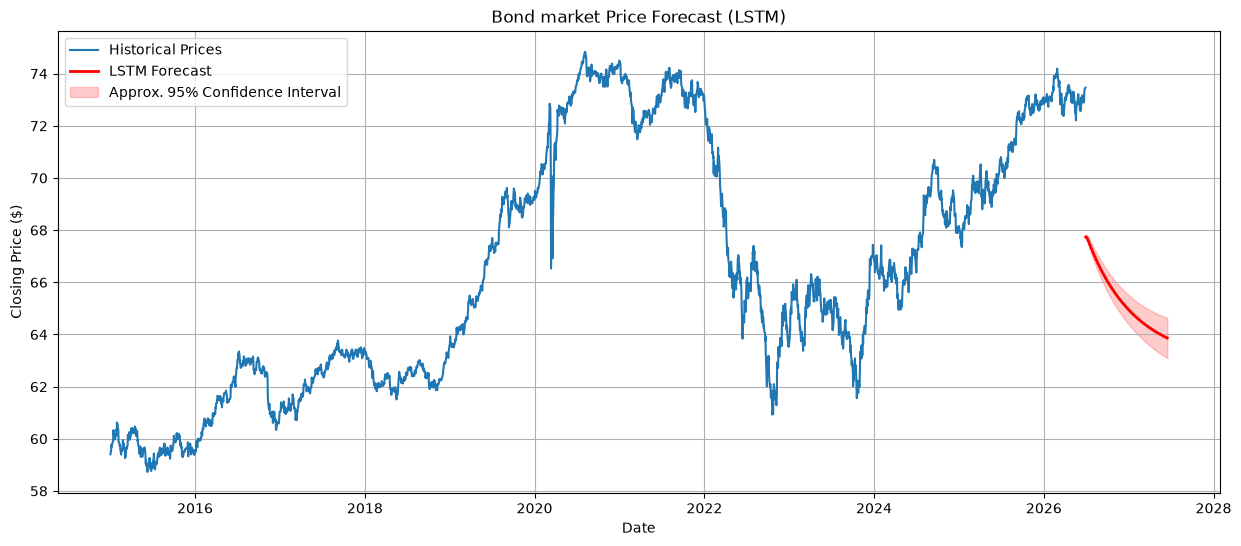

In [52]:
plt.figure(figsize=(15,6))

plt.plot(
    bnd.index,
    bnd["Close"],
    label="Historical Prices"
)

plt.plot(
    future_dates,
    future_predictions,
    color="red",
    linewidth=2,
    label="LSTM Forecast"
)

plt.fill_between(
    future_dates,
    lower,
    upper,
    color="red",
    alpha=0.2,
    label="Approx. 95% Confidence Interval"
)

plt.title("Bond market Price Forecast (LSTM)")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.legend()
plt.grid(True)

plt.show()